In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Φορτώνουμε embeddings και labels
models_path = os.path.expanduser("~/igbert-embedding-analysis/results/models/")
figures_path = os.path.expanduser("~/igbert-embedding-analysis/results/figures/")

embeddings_l30 = np.load(models_path + "embeddings_l30.npy")
embeddings_l15 = np.load(models_path + "embeddings_l15.npy")
labels = pd.read_csv(models_path + "labels.csv")

print(f"Embeddings layer 30: {embeddings_l30.shape}")
print(f"Embeddings layer 15: {embeddings_l15.shape}")
print(f"Labels: {labels.shape}")

Embeddings layer 30: (4500, 1024)
Embeddings layer 15: (4500, 1024)
Labels: (4500, 2)


In [2]:
def run_linear_probe(embeddings, labels_series, label_name, layer_name):
    """
    Εκπαιδεύει logistic regression και αξιολογεί την απόδοσή του.
    """
    # Encode labels σε αριθμούς
    le = LabelEncoder()
    y = le.fit_transform(labels_series)
    
    # Train/test split 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Logistic Regression
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    
    # Αξιολόγηση
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Layer: {layer_name} | Label: {label_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc*100:.1f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    return acc, y_test, y_pred, le.classes_

# Τρέχουμε για V-gene family
acc_l30_vfam, y_test_l30, y_pred_l30, classes_vfam = run_linear_probe(
    embeddings_l30, labels['v_family'], "V-gene Family", "Layer 30"
)

acc_l15_vfam, _, _, _ = run_linear_probe(
    embeddings_l15, labels['v_family'], "V-gene Family", "Layer 15"
)


Layer: Layer 30 | Label: V-gene Family
Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

       IGHV1       1.00      1.00      1.00       300
       IGHV3       1.00      1.00      1.00       300
       IGHV4       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


Layer: Layer 15 | Label: V-gene Family
Accuracy: 99.9%

Classification Report:
              precision    recall  f1-score   support

       IGHV1       1.00      1.00      1.00       300
       IGHV3       1.00      1.00      1.00       300
       IGHV4       1.00      1.00      1.00       300

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



In [3]:
# Τρέχουμε για isotype
acc_l30_iso, y_test_iso_l30, y_pred_iso_l30, classes_iso = run_linear_probe(
    embeddings_l30, labels['isotype'], "Isotype", "Layer 30"
)

acc_l15_iso, _, _, _ = run_linear_probe(
    embeddings_l15, labels['isotype'], "Isotype", "Layer 15"
)


Layer: Layer 30 | Label: Isotype
Accuracy: 70.6%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.69      0.67      0.68       300
        IGHG       0.71      0.73      0.72       300
        IGHM       0.72      0.72      0.72       300

    accuracy                           0.71       900
   macro avg       0.71      0.71      0.71       900
weighted avg       0.71      0.71      0.71       900


Layer: Layer 15 | Label: Isotype
Accuracy: 75.0%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.74      0.68      0.71       300
        IGHG       0.77      0.79      0.78       300
        IGHM       0.74      0.78      0.76       300

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.75      0.75      0.75       900




Layer: Layer 15 | Label: Isotype
Accuracy: 75.0%

Classification Report:
              precision    recall  f1-score   support

        IGHA       0.74      0.68      0.71       300
        IGHG       0.77      0.79      0.78       300
        IGHM       0.74      0.78      0.76       300

    accuracy                           0.75       900
   macro avg       0.75      0.75      0.75       900
weighted avg       0.75      0.75      0.75       900



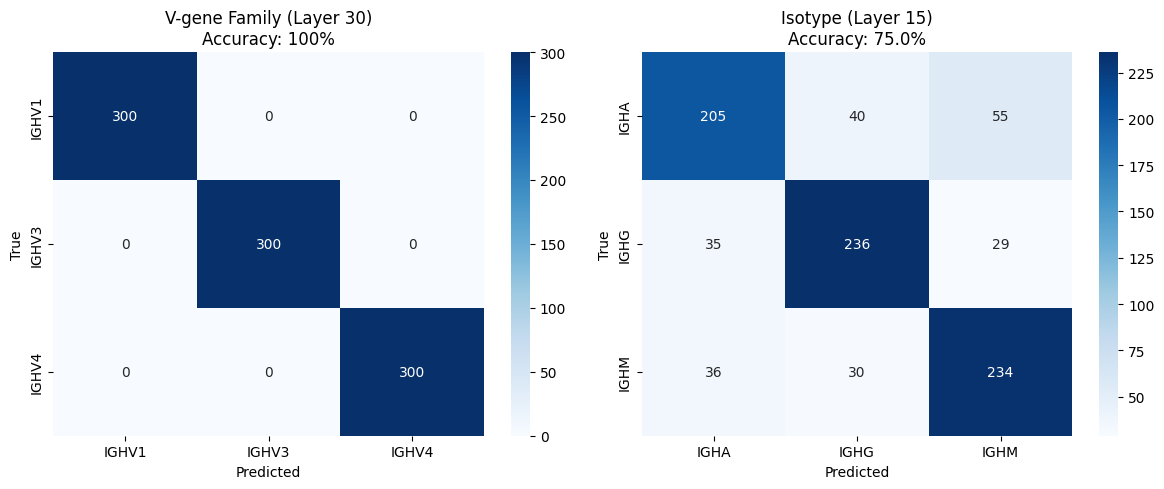

Αποθηκεύτηκε: confusion_matrices.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix για V-gene (layer 30)
cm_vfam = confusion_matrix(y_test_l30, y_pred_l30)
sns.heatmap(cm_vfam, annot=True, fmt='d', ax=axes[0],
            xticklabels=classes_vfam, yticklabels=classes_vfam,
            cmap='Blues')
axes[0].set_title(f"V-gene Family (Layer 30)\nAccuracy: 100%")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")

# Confusion matrix για isotype (layer 15, το καλύτερο)
acc_l15_iso_rerun, y_test_iso, y_pred_iso, classes_iso = run_linear_probe(
    embeddings_l15, labels['isotype'], "Isotype", "Layer 15"
)
cm_iso = confusion_matrix(y_test_iso, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', ax=axes[1],
            xticklabels=classes_iso, yticklabels=classes_iso,
            cmap='Blues')
axes[1].set_title(f"Isotype (Layer 15)\nAccuracy: 75.0%")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(figures_path + "confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: confusion_matrices.png")

In [5]:
# Φορτώνουμε το ενημερωμένο dataset
data_path = os.path.expanduser("~/igbert-embedding-analysis/data/processed/sequences_balanced.csv")
df = pd.read_csv(data_path)

print("Νέες ιδιότητες:")
print(f"\nJ-gene families:")
print(df['j_family'].value_counts())
print(f"\nCDR3 length stats:")
print(df['junction_aa_length'].describe())
print(f"\nV-identity (somatic hypermutation) stats:")
print(df['v_identity'].describe())

Νέες ιδιότητες:

J-gene families:
j_family
IGHJ4    2029
IGHJ6    1552
IGHJ5     412
IGHJ3     370
IGHJ2      83
IGHJ1      54
Name: count, dtype: int64

CDR3 length stats:
count    4500.000000
mean       18.689556
std         4.420781
min         7.000000
25%        16.000000
50%        18.000000
75%        22.000000
max        62.000000
Name: junction_aa_length, dtype: float64

V-identity (somatic hypermutation) stats:
count    4500.000000
mean       94.614849
std         4.335686
min        69.767000
25%        91.566000
50%        94.971000
75%        98.814000
max       100.000000
Name: v_identity, dtype: float64


In [6]:
# Προετοιμασία νέων labels

# J-gene: κρατάμε μόνο IGHJ4, IGHJ5, IGHJ6
df_j = df[df['j_family'].isin(['IGHJ4', 'IGHJ5', 'IGHJ6'])].copy()
print(f"Sequences για J-gene probe: {len(df_j)}")

# CDR3 length: μετατρέπουμε σε κατηγορίες
df['cdr3_category'] = pd.cut(
    df['junction_aa_length'],
    bins=[0, 15, 21, 100],
    labels=['short', 'medium', 'long']
)
print(f"\nCDR3 categories:")
print(df['cdr3_category'].value_counts())

# V-identity: μετατρέπουμε σε κατηγορίες
df['mutation_category'] = pd.cut(
    df['v_identity'],
    bins=[0, 93, 98, 100],
    labels=['high_mutation', 'moderate', 'low_mutation']
)
print(f"\nMutation categories:")
print(df['mutation_category'].value_counts())

Sequences για J-gene probe: 3993

CDR3 categories:
cdr3_category
medium    2229
long      1223
short     1048
Name: count, dtype: int64

Mutation categories:
mutation_category
high_mutation    1562
moderate         1560
low_mutation     1378
Name: count, dtype: int64


In [7]:
# Τρέχουμε linear probe για όλες τις νέες ιδιότητες

# Χρειαζόμαστε τα embeddings aligned με τα νέα labels
# Τα embeddings είναι αποθηκευμένα με την ίδια σειρά με το παλιό dataset
# οπότε μπορούμε να τα χρησιμοποιήσουμε απευθείας

# J-gene (μόνο για τις 3993 sequences που έχουν IGHJ4/5/6)
j_mask = df['j_family'].isin(['IGHJ4', 'IGHJ5', 'IGHJ6'])
acc_l30_jgene, _, _, _ = run_linear_probe(
    embeddings_l30[j_mask], df[j_mask]['j_family'], "J-gene Family", "Layer 30"
)

acc_l15_jgene, _, _, _ = run_linear_probe(
    embeddings_l15[j_mask], df[j_mask]['j_family'], "J-gene Family", "Layer 15"
)

# CDR3 length
acc_l30_cdr3, _, _, _ = run_linear_probe(
    embeddings_l30, df['cdr3_category'], "CDR3 Length", "Layer 30"
)

acc_l15_cdr3, _, _, _ = run_linear_probe(
    embeddings_l15, df['cdr3_category'], "CDR3 Length", "Layer 15"
)

# Somatic hypermutation
acc_l30_mut, _, _, _ = run_linear_probe(
    embeddings_l30, df['mutation_category'], "Somatic Hypermutation", "Layer 30"
)

acc_l15_mut, _, _, _ = run_linear_probe(
    embeddings_l15, df['mutation_category'], "Somatic Hypermutation", "Layer 15"
)


Layer: Layer 30 | Label: J-gene Family
Accuracy: 98.7%

Classification Report:
              precision    recall  f1-score   support

       IGHJ4       0.99      0.99      0.99       406
       IGHJ5       0.96      0.94      0.95        82
       IGHJ6       1.00      1.00      1.00       311

    accuracy                           0.99       799
   macro avg       0.98      0.98      0.98       799
weighted avg       0.99      0.99      0.99       799


Layer: Layer 15 | Label: J-gene Family
Accuracy: 98.5%

Classification Report:
              precision    recall  f1-score   support

       IGHJ4       0.98      0.99      0.99       406
       IGHJ5       0.95      0.91      0.93        82
       IGHJ6       1.00      0.99      1.00       311

    accuracy                           0.98       799
   macro avg       0.98      0.97      0.97       799
weighted avg       0.98      0.98      0.98       799


Layer: Layer 30 | Label: CDR3 Length
Accuracy: 95.6%

Classification Report:


In [8]:
# Συνοπτικός πίνακας αποτελεσμάτων
results = {
    'Property': ['V-gene family', 'J-gene family', 'CDR3 length', 
                 'Somatic Hypermutation', 'Isotype'],
    'Layer 15': [99.9, 98.5, 99.0, 88.2, 75.0],
    'Layer 30': [100.0, 98.7, 95.6, 90.2, 70.6],
    'Random baseline': [33.3, 33.3, 33.3, 33.3, 33.3]
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

             Property  Layer 15  Layer 30  Random baseline
        V-gene family      99.9     100.0             33.3
        J-gene family      98.5      98.7             33.3
          CDR3 length      99.0      95.6             33.3
Somatic Hypermutation      88.2      90.2             33.3
              Isotype      75.0      70.6             33.3


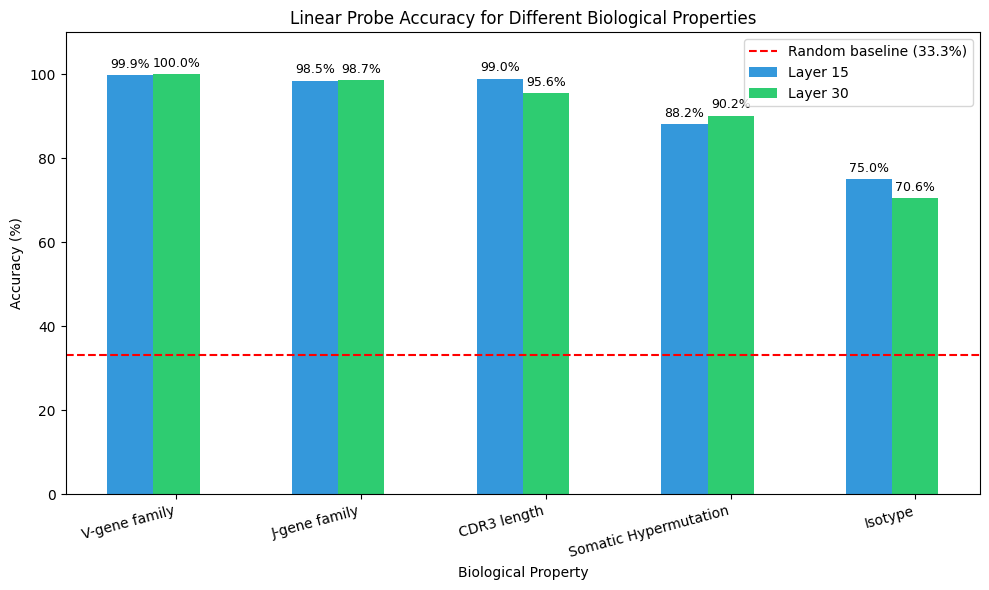

Αποθηκεύτηκε: linear_probe_summary.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(results['Property']))
width = 0.25

bars1 = ax.bar([i - width for i in x], results['Layer 15'], 
               width=width, label='Layer 15', color='#3498db')
bars2 = ax.bar(x, results['Layer 30'], 
               width=width, label='Layer 30', color='#2ecc71')
ax.axhline(y=33.3, color='red', linestyle='--', label='Random baseline (33.3%)')

ax.set_xlabel('Biological Property')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Linear Probe Accuracy for Different Biological Properties')
ax.set_xticks(x)
ax.set_xticklabels(results['Property'], rotation=15, ha='right')
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(figures_path + "linear_probe_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: linear_probe_summary.png")